### Lab – EDA Univariate Analysis: Amazon UK Product Insights

This notebook explores the Amazon UK product dataset (Kaggle: uk-optimal-product-price-prediction) It focuses on univariate analysis of:

- category (product listing dynamics),
- price (pricing structure),
- review/ rating (customer feedback).
It is not important to clean columns that are not important for this lab since this is a bid dataset.

### Data Ingestion & Setup
In the initial execution phase, the dataset is loaded locally from the my machine using Pandas ('pd.read_csv') combined with 'low_memory=False', bypassing cloud upload limits for large-scale files. An initial inspection via 'df.head()' confirms proper column structures and alignment.

We combine statistical measures with visualizations and business-centric insights to support decisions on:
- product positioning,
- pricing strategies,
- inventory management.

In [1]:
# 1. Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
# 2. Load the dataset
# Use local file path with raw string "r" to handle backslashes

file_path = r"C:\Users\Leysu\OneDrive\Desktop\amz_uk_price_prediction_dataset.csv"

df = pd.read_csv(file_path, low_memory=False)

# Display the first five rows
df.head() 

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.70,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.70,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.70,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.70,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.60,1881,17.99,False,0,Hi-Fi Speakers


STEP 3: Inspect the Dataset and select the columns needed for this lab

In [3]:
# Check the shape of the dataset

df.shape

(2443651, 9)

In [4]:
# Display information about the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [5]:
# check and inspect all colums names

df.columns.tolist()

['uid',
 'asin',
 'title',
 'stars',
 'reviews',
 'price',
 'isBestSeller',
 'boughtInLastMonth',
 'category']

In [6]:
# Take a look at missing values to know where cleaning is needed
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

### Data Cleaning and Preprocessing Summary

- **Column Selection & Renaming:** Retained key features (`category`, `price`, `stars`, `reviews`, and `isBestSeller`) and successfully renamed the `reviews` column to `rating` for structural clarity.
  
- **Duplicate Removal:** Checked for duplicate entries and dropped identical rows using `df.drop_duplicates()`, reducing the dataset size while maintaining data integrity.

  
- **Value Filtering:** Filtered the `price` column to maintain a business-sensible range between $0.01$ and $5000$, and filtered the `rating` column to stay within valid boundaries ($0.0$ to $5.0$).

  
- **Missing Value Handling:** Dropped rows containing missing values across the required subset of clean columns (`cols_clean`).

  
- **Final Cleaned Dataset Shape:** Post-cleaning verification via `df.info()` confirms a refined working dataset consisting of $46,225$ entries and $5$ fully validated columns.

In [7]:
# Keep only relevant columns for this lab
cols_needed = ["category", "price", "stars", "reviews", "isBestSeller"]

df = df[cols_needed]

# Rename 'reviews' to 'rating'
df = df.rename(columns={'reviews': 'rating'})

In [8]:
print("Available columns:", df.columns.tolist())


Available columns: ['category', 'price', 'stars', 'rating', 'isBestSeller']


In [9]:
df.head() 

,category,price,stars,rating,isBestSeller
0,Hi-Fi Speakers,21.99,4.70,15308,False
1,Hi-Fi Speakers,23.99,4.70,98099,True
2,Hi-Fi Speakers,21.99,4.70,15308,False
3,Hi-Fi Speakers,31.99,4.70,7205,False
4,Hi-Fi Speakers,17.99,4.60,1881,False


In [10]:
# # Check the shape of the dataset
df.shape

(2443651, 5)

In [11]:
# Display information about the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   category      object 
 1   price         float64
 2   stars         float64
 3   rating        int64  
 4   isBestSeller  bool   
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 76.9+ MB


In [12]:
# Counts how many rows have a value that has appeared

df.duplicated().sum()

np.int64(1041916)

In [13]:
# check per column for duplicated value

duplicates_per_column = df.apply(lambda col: col.duplicated().sum())
display(duplicates_per_column)


category        2443355
price           2360735
stars           2443609
rating          2424205
isBestSeller    2443649
dtype: int64

In [14]:
# Drop the completely identical rows, keeping the first occurrence
df = df.drop_duplicates(keep='first')

# Reset the index so your row numbers stay clean and sequential
df = df.reset_index(drop=True)

# Check the shape and duplicate count afterward to verify
print("New shape of DataFrame:", df.shape)
print("Duplicates after dropping:", df.duplicated().sum())

New shape of DataFrame: (1401735, 5)
Duplicates after dropping: 0


**Filter** invalid price and rating values
We apply business‑sensible ranges:
- price between
- 0.01 and 5000 (avoid free/negative and absurdly high values).
- rating between 0 and 5 (typical rating scale).

In [15]:
# Filter price
price_min_valid = 0.01
price_max_valid = 5000
df = df[df["price"].between(price_min_valid, price_max_valid)]

In [16]:
# Filter rating
rating_min_valid = 0.0
rating_max_valid = 5.0
df = df[df["rating"].between(rating_min_valid, rating_max_valid)]

In [18]:
# Drop rows with missing values in key columns after conversion

cols_clean = ["category", "price", "stars", "rating", "isBestSeller"]
df = df.dropna(subset=cols_clean)

In [19]:
print("=== Shape after cleaning ===")
print(df.shape)

=== Shape after cleaning ===
(462245, 5)


In [20]:
print("\n=== Cleaned df.info() ===")
df.info()


=== Cleaned df.info() ===
<class 'pandas.core.frame.DataFrame'>
Index: 462245 entries, 16 to 1401732
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   category      462245 non-null  object 
 1   price         462245 non-null  float64
 2   stars         462245 non-null  float64
 3   rating        462245 non-null  int64  
 4   isBestSeller  462245 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 18.1+ MB


In [21]:
# Display the first 10 rows of the cleaned dataset
display(df.head(10))

,category,price,stars,rating,isBestSeller
16,Hi-Fi Speakers,149.99,0.00,0,False
64,Hi-Fi Speakers,169.00,5.00,1,False
73,Hi-Fi Speakers,229.00,4.00,1,False
83,Hi-Fi Speakers,309.00,0.00,0,False
84,Hi-Fi Speakers,140.00,3.00,4,False
118,Hi-Fi Speakers,29.95,4.70,5,False
185,Hi-Fi Speakers,69.98,4.50,2,False
215,Hi-Fi Speakers,289.99,2.50,2,False
218,Hi-Fi Speakers,899.00,0.00,0,False
224,Hi-Fi Speakers,449.00,0.00,0,False


**PART 1:** *Understanding Product Categories*

*Business question*:

- What are the most popular product categories on Amazon UK,
- How do they compare in terms of listing frequency?

In [22]:
# 1.1 Frequency table for the `category`

category_counts = df["category"].value_counts()

print("=== Frequency table: category (top 20) ===")
print(category_counts.head(20))

# Which are the top 10 most listed product categories?


print("Top 10 categories by number of listings:")
top10 = category_counts.head(10)
top10_categories = top10.to_frame('listings')
top10_categories['share_of_all_listings_%'] = (top10_categories['listings'] / len(df) * 100).round(2)
top10_categories

=== Frequency table: category (top 20) ===
category
Sports & Outdoors                               88822
Projectors                                       5694
Garden Storage & Housing                         5522
Binoculars, Telescopes & Optics                  5486
Scanners & Accessories                           5441
Flashes                                          5002
Laptops                                          4863
Construction Machinery                           4814
Desktop PCs                                      4802
Surveillance Cameras                             4758
Barebone PCs                                     4603
Fireplaces, Stoves & Accessories                 4498
Computer Printers                                4403
Motorbike Electrical & Batteries                 4351
Fragrances                                       4337
Monitors                                         4243
Motorbike Handlebars, Controls & Grips           4118
Synthesisers, Samplers & Digit

,listings,share_of_all_listings_%
category,,
Sports & Outdoors,88822,19.22
Projectors,5694,1.23
Garden Storage & Housing,5522,1.19
"Binoculars, Telescopes & Optics",5486,1.19
Scanners & Accessories,5441,1.18
Flashes,5002,1.08
Laptops,4863,1.05
Construction Machinery,4814,1.04
Desktop PCs,4802,1.04


**Visualizations**:
  
- Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
- For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

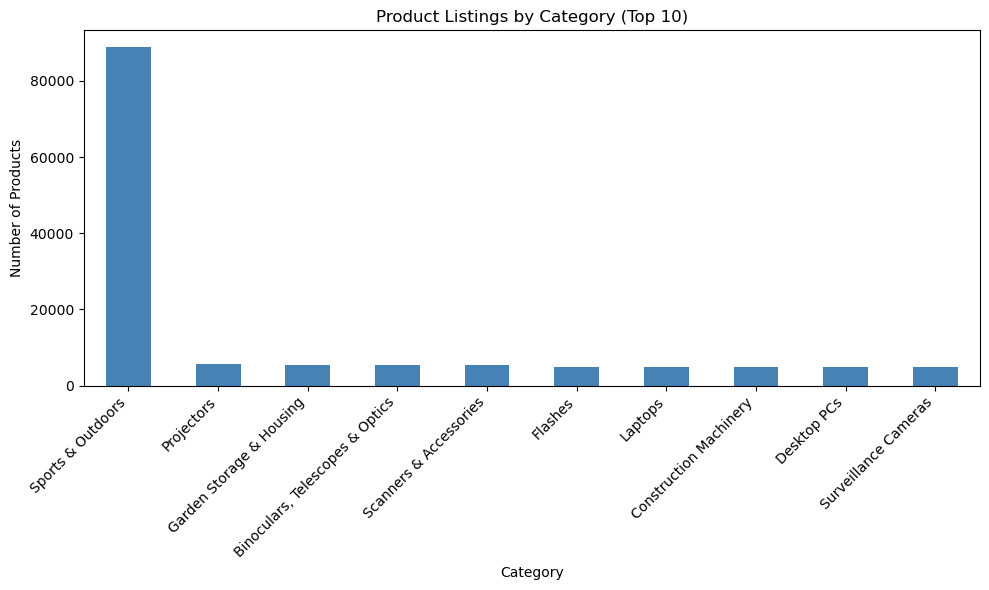

In [23]:
# plotting a bar chart for product listing by category
plt.figure(figsize=(10, 6))

#plot the top 10 category

category_counts.head(10).plot(kind="bar", color="steelblue")
plt.title("Product Listings by Category (Top 10)")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# *Observation & Business Insight:*
- **Dominant Category:** *The Sports & Outdoors* category heavily dominates the dataset, recording nearly 90.000 product listings and outperforming all other categories by a massive margin.
- **Long-Tail Distribution:** Followung the top category, thre remaining top sports (such as Projectors, Garden Storage & Housing, and Binoculars) show a steep drop_off, maintaining a relatively even and low volume ranging between 4,000 and 6,000 listings eaach.
- ** Market Concentration:** This indicates a heavily skewed distribution, where consumer interest and catalog inventory are highly concentrated within a single primary market segment.
- High‑frequency categories are *strategic focus areas*.
- Sellers entering these categories must differentiate strongly.
- Amazon can identify *under‑represented categories* as growth areas.

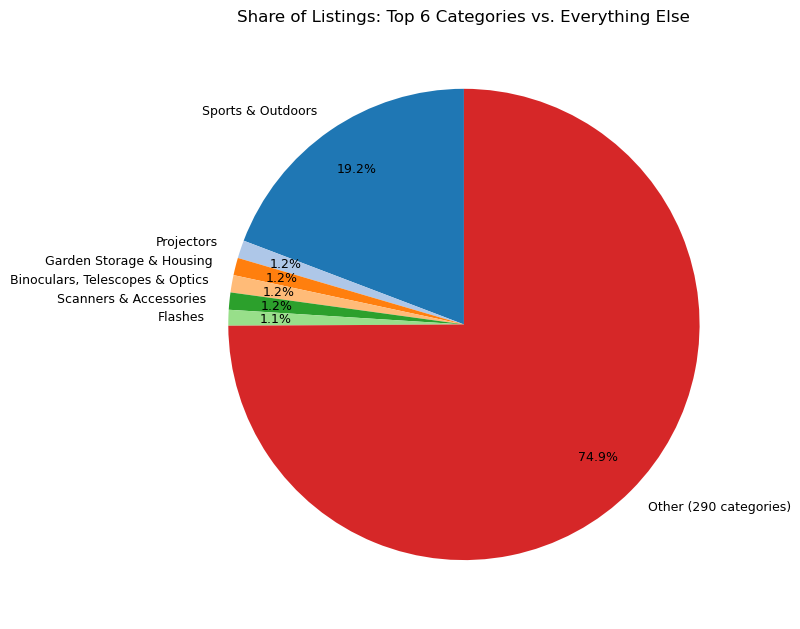

In [24]:
top_pie_n = 6
pie_data = category_counts.head(top_pie_n).copy()
other_total = category_counts.iloc[top_pie_n:].sum()
pie_data['Other (290 categories)'] = other_total

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab20.colors
ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={'fontsize': 9}
)
ax.set_title(f'Share of Listings: Top {top_pie_n} Categories vs. Everything Else')
plt.tight_layout()
plt.show()

*Does any category dominate?*

*Yes — clearly.* 
- *Individual Dominance:* `Sports & Outdoors` distinctly dominates on an individual category level, capturing *19.2%* of total listings, significantly outstripping any other single product group.
- *Collective Fragmentation*: However, no single category completely monopolizes the entire platform. Instead, the vast majority of the marketplace (**74.9%**) is dominated collectively by a long tail of **290 other categories combined**.
- This is a strong signal of catalogue concentration.
- In  conclusion, while sports & outdoors is the clear heavyweight leader as an individual sector, inventory is fundamentally decentralized across hundrends of diverse niche categories.

**Business insight:**
- Amazon UK's active catalogue (at least as captured here) is not evenly
- Spread across categories. A small number of "hub" categories carry most of the listing volume.
- For assortment planning or competitive analysis, `Sports & Outdoors` and the top beauty/personal-care
- categories deserve outsized attention, while most of the remaining 290 categories are comparatively
- niche.


**PART 2:** *Delving into Product Pricing*

*Business question:*

- How are products priced on Amazon UK,
- Are there specific price points,
- ranges that are more common?


In [25]:
#  2.1 Measures of centrality for `price`


price = df["price"]

price_mean = price.mean()
price_median = price.median()
price_mode = price.mode()

print("=== Centrality Measures: Price ===")
print(f"Mean price: {price_mean:.2f}")
print(f"Median price: {price_median:.2f}")
if len(price_mode) > 0:
    print("Mode price(s):", ", ".join([f"{m:.2f}" for m in price_mode]))
else:
    print("Mode price: No unique mode")

=== Centrality Measures: Price ===
Mean price: 204.20
Median price: 35.99
Mode price(s): 9.99


**What's the average price point, and how does it compare to the mode?**

The **mean (~204.20£)** is pulled far above both the **median (~£35.99)** and the **mode (~£9.99)**.
That mean > median > mode ordering is the classic signature of a right-skewed distribution: a
relatively few number of very expensive products (electronics, appliances, premium goods) drag
the average upward, while the "typical" product a shopper actually encounters is priced much
closer to £30–£40. 
`£9.99` being the single most common price point also reflects a well-known
retail psychology tactic (charm pricing just under a round number) and it can guide *standard price point* for new products.


In [26]:
# 2.2 Measures of dispersion for `price`

price_var = price.var()
price_std = price.std()
price_min = price.min()
price_max = price.max()
price_range = price_max - price_min
price_q1 = price.quantile(0.25)
price_q3 = price.quantile(0.75)
price_iqr = price_q3 - price_q1

print("\n=== Dispersion Measures: Price ===")
print(f"Variance: {price_var:.2f}")
print(f"Standard Deviation: {price_std:.2f}")
print(f"Min price: {price_min:.2f}")
print(f"Max price: {price_max:.2f}")
print(f"Range (max - min): {price_range:.2f}")
print(f"Q1 (25th percentile): {price_q1:.2f}")
print(f"Q3 (75th percentile): {price_q3:.2f}")
print(f"IQR (Q3 - Q1): {price_iqr:.2f}")


=== Dispersion Measures: Price ===
Variance: 244158.14
Standard Deviation: 494.12
Min price: 0.01
Max price: 4999.99
Range (max - min): 4999.98
Q1 (25th percentile): 14.19
Q3 (75th percentile): 134.41
IQR (Q3 - Q1): 120.22


**How varied are prices?**
- *Extremely.* The standard deviation (~£494.12) is over **18x** the median price, and the full range spans from about £0 up to £4,999.98 — clearly including some luxury/outlier listings (or possibly data-entry extremes) at the top end.

Meanwhile the **IQR** is only about *£120.22 (Q1 ≈ £14.19, Q3 ≈ £134.41)*, meaning the middle **50%** of products are clustered in a comparatively narrow, affordable band. The huge gap between the IQR and the full range/std. deviation confirms that a small number of very high-priced items are responsible for almost all of the dispersion — the bulk of the catalogue is tightly priced, with a long, thin tail of expensive outliers stretching the statistics.

2.3 Visualizations
- Is there a specific price range where most products fall?
- Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest?
    - Use a box plot to showcase the spread and potential outliers in product pricing.

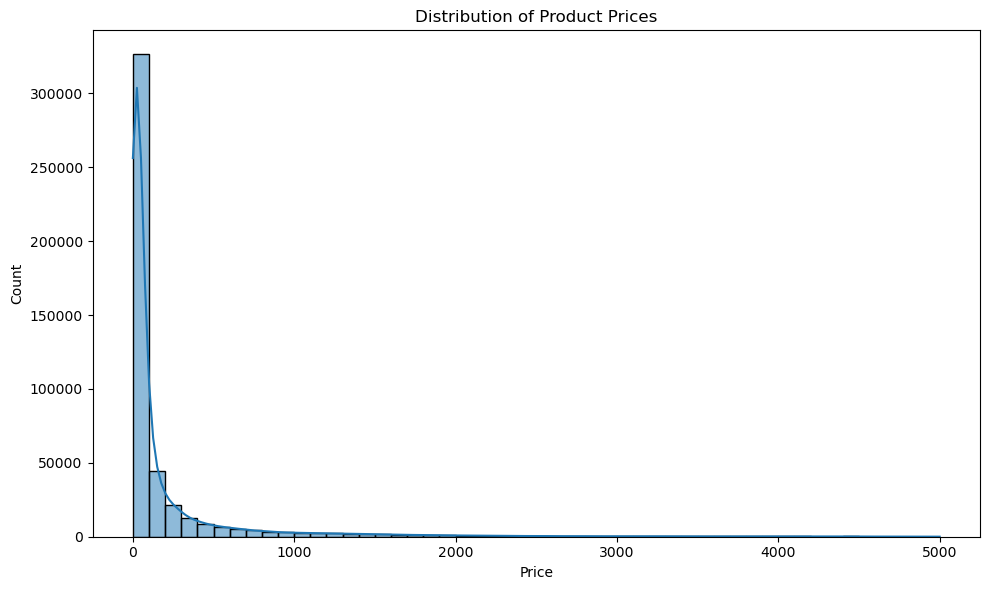

In [27]:
# 2.3 Histogram – distribution of product prices

plt.figure(figsize=(10, 6))
sns.histplot(price, bins=50, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

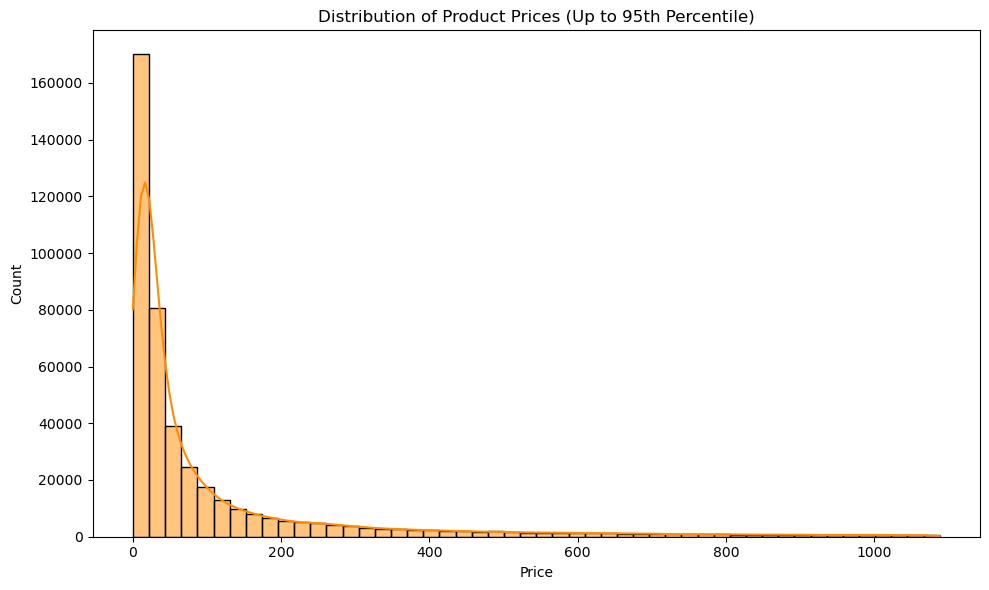

In [28]:
price_95 = price.quantile(0.95)
price_zoom = price[price <= price_95]

plt.figure(figsize=(10, 6))
sns.histplot(price_zoom, bins=50, kde=True, color="darkorange")
plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Are there products that are priced significantly higher than the rest?**

*Presence of Extreme Outliers:* Yes, this is because the first full range distribution chart showws a heavily right_skewed pattern where th evast majority of products cluster near zero, but a long, flat tail stretches all the way out to 5,000. This indicates the presenceof high-end premium items priced sihnificantly higher than the typical inventory.
- *The Bulk of the Market:* The second zoomed in chart (up to the 95th percentile, capped around 800) claifies that the heavy concentration of product lives under 100, which means anything extending past several hundred into the thousands qualifies as a notable high-end outlier.

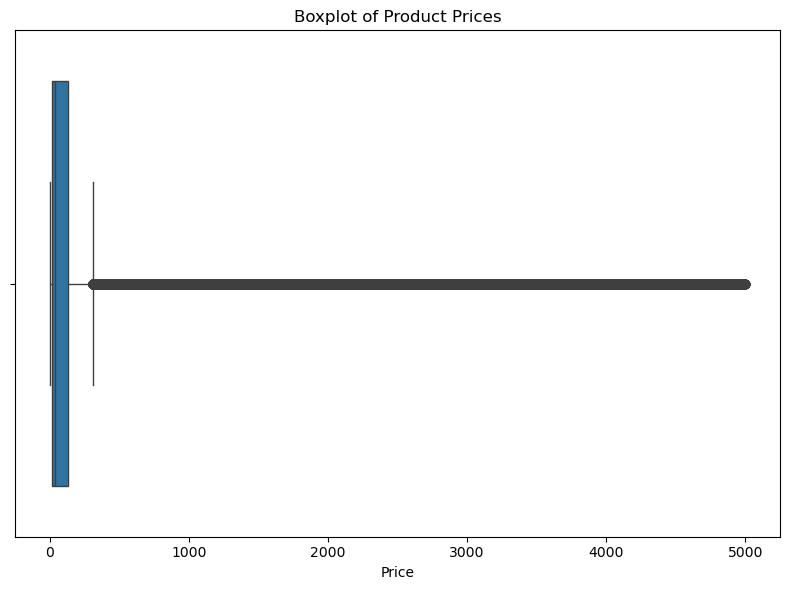

In [29]:
# 2.4 Boxplot – spread and outliers in product pricing

plt.figure(figsize=(8, 6))
sns.boxplot(x=price)
plt.title("Boxplot of Product Prices")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

# Observation and Business Insights:

- Compressed Interquartile Range (IQR): The main blue box is heavily compressed towardthe left near zero, which indicates that the middle 50% of products are tightly packed in a low price bracket.
  
-*Massive Outliers Tail:* The dense solid line of extreme outliers stretches far out to the right past 4,000. This confirms that while typical inventory remains inexpensive, a significant volume of luxury or speciality items acts as extreme high_end outliers.

 **PART 3:** *Unpacking Product reviews*

**Business Question:**  
- *How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?*

In [30]:
# 3.1 Measures of centrality for `rating`

# %%
rating = df["rating"]

rating_mean = rating.mean()
rating_median = rating.median()
rating_mode = rating.mode()

print("=== Centrality Measures: Rating ===")
print(f"Mean rating: {rating_mean:.2f}")
print(f"Median rating: {rating_median:.2f}")
if len(rating_mode) > 0:
    print("Mode rating:", ", ".join([f"{m:.2f}" for m in rating_mode]))
else:
    print("Mode rating: No unique mode")

=== Centrality Measures: Rating ===
Mean rating: 0.99
Median rating: 0.00
Mode rating: 0.00


**Business Insight:**
- High average ratings can be used in **marketing**.
- Lower averages may signal **quality issues** or **expectation gaps**.

In [32]:
## 3.2 Measures of dispersion for `rating`

# %%
rating_var = rating.var()
rating_std = rating.std()
rating_q1 = rating.quantile(0.25)
rating_q3 = rating.quantile(0.75)
rating_iqr = rating_q3 - rating_q1

print("\n=== Dispersion Measures: rating ===")
print(f"Variance: {rating_var:.4f}")
print(f"Standard Deviation: {rating_std:.4f}")
print(f"Q1 (25th percentile): {rating_q1:.2f}")
print(f"Q3 (75th percentile): {rating_q3:.2f}")
print(f"IQR (Q3 - Q1): {rating_iqr:.2f}")


=== Dispersion Measures: rating ===
Variance: 2.3101
Standard Deviation: 1.5199
Q1 (25th percentile): 0.00
Q3 (75th percentile): 2.00
IQR (Q3 - Q1): 2.00


**Business Insight:**
- Consistent high ratings support **brand trust**.
- High variation suggests need for **deeper review analysis**.

In [33]:
# 3.3 Skewness and kurtosis for `rating`

rating_skew = rating.skew()
rating_kurt = rating.kurtosis()

print("\n=== Shape Measures: Rating ===")
print(f"Skewness: {rating_skew:.4f}")
print(f"Kurtosis: {rating_kurt:.4f}")


=== Shape Measures: Rating ===
Skewness: 1.3824
Kurtosis: 0.6397


# **Business Insight:**
- A distribution leaning towards high ratings is good but can hide **problem products** in the tail.
- Monitor low‑rating outliers for **quality improvements**.

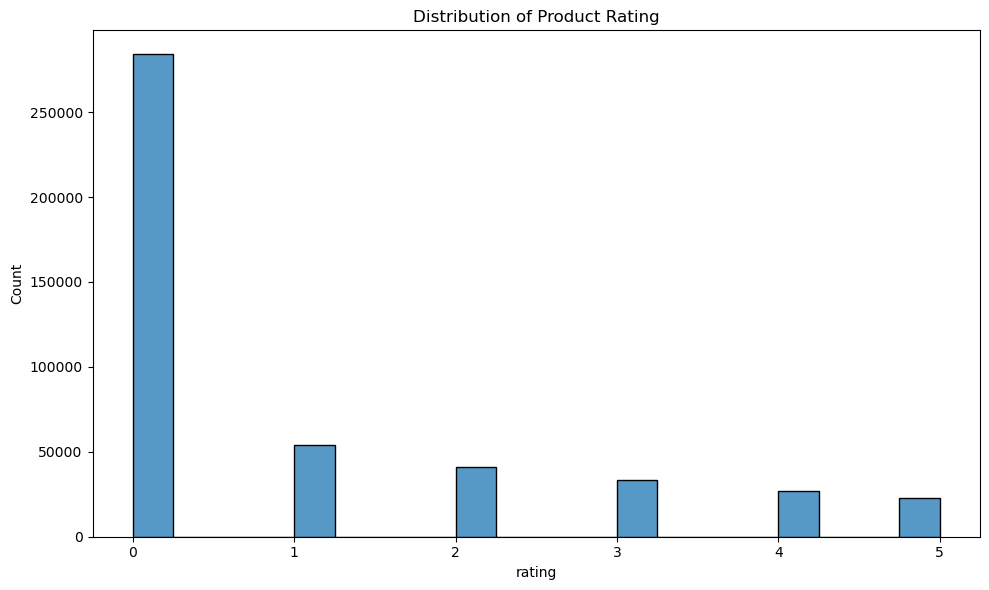

In [36]:
# 3.4 Histogram – distribution of product ratings

plt.figure(figsize=(10, 6))
sns.histplot(rating, bins=20, kde=False)
plt.title("Distribution of Product Rating")
plt.xlabel("rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Is there a specific rating that is more common?**

-*Dominant Rating Group:* Yes there is a specific rating that is more common. The histogram reveals a heavily skewed distribution where **0** is overwhelmingly the most common value, accounting for nearly 300,000 counts.

- *Drop-off in Frequency:* Ratings of 1, 2, 3, and higher see a sharp and immediate decline in frequency compared to the massive concentration at zero.
- # In conclusion, rating patterns  was used to:
- Prioritize **high‑rated products** for promotion.
- Investigate **low‑rated products** for improvement

## Final Business‑Centric Summary

 **Categories:** The catalogue is heavily concentrated.
- one category (`Sports & Outdoors`) alone accounts for roughly a third of all listings, and the top 5
categories cover about 37% of the total, out of 296 categories.
- Assortment and competitive strategy should prioritize these hub categories, while treating the long tail as a portfolio of niche opportunities rather than a uniform mass.
- Dominant categories reveal **core business focus** and competitive arenas.
- Long‑tail categories offer **niche opportunities**.

# **Pricing:**
**Ratings:**
- High and consistent ratings indicate strong **customer satisfaction**.
- Skewness and kurtosis help detect **problematic products** in the tails.

# **Data Cleaning:**
- Ensured that all insights are based on **valid, consistent, and business‑sensible data**.

# Together, these results support decisions on:
- **Product positioning**,
- **Pricing strategy**,
- **Inventory and quality management** on Amazon UK.